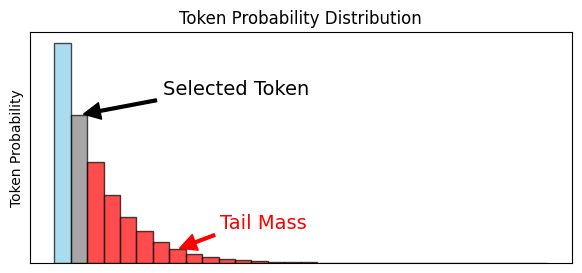

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Generate exponential distribution data
np.random.seed(42)
data = np.random.exponential(scale=0.5, size=100000)

# Define threshold for coloring
threshold = 0.30


"""A no-op context manager that does nothing."""
class NoOpContextManager:
    def __enter__(self):
        return None
    
    def __exit__(self, exc_type, exc_val, exc_tb):
        return False


with NoOpContextManager(): # plt.xkcd()  # Enable xkcd style
    # Create figure and axis with aspect ratio 1.0
    fig, ax = plt.subplots(figsize=(7, 3))
    
    # Create histogram with custom colors based on threshold and density normalization
    n, bins, patches = ax.hist(data, bins=30, alpha=0.7, edgecolor='black', density=True)
    
    # Color bars above threshold differently and add token labels
    for i, patch in enumerate(patches):
        if bins[i] < threshold and i < len(bins) and bins[i+1] >= threshold:
            patch.set_facecolor('grey')
            patch.set_edgecolor('black')
        elif bins[i] >= threshold:
            patch.set_facecolor('red')        
        else:
            patch.set_facecolor('skyblue')
            
        # Add vertical text in each bar with token number
        bin_center = (bins[i] + bins[i+1]) / 2
        bin_height = n[i]
        #if bin_height > 0.05:  # Only add text if bar is tall enough
        #    ax.text(bin_center, 0.1, f"Token {i+1}", 
        #           rotation=90, ha='center', va='center', fontsize=5, color='black')
    
    # Add labels and title
    ax.set_xlabel('Value')
    ax.set_ylabel('Token Probability')
    ax.set_title('Token Probability Distribution')
    # Format y-axis as percentages
    from matplotlib.ticker import PercentFormatter
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    
    # Find a midway red bar to annotate for tail mass
    midway_index = len(patches) // 4  # Adjust to find a red bar midway
    for i in range(midway_index, len(patches)):
        if patches[i].get_facecolor()[0] == 1.0:  # Check if the bar is red
            midway_red_bar_index = i
            break
    
    # Add "Tail Mass" text as annotation pointing to a midway red bar
    midway_bin_center = (bins[midway_red_bar_index] + bins[midway_red_bar_index+1]) / 2
    midway_bin_height = n[midway_red_bar_index]
    ax.annotate("Tail Mass", 
                xy=(midway_bin_center, midway_bin_height),
                xytext=(midway_bin_center + 0.5, midway_bin_height + 0.15),
                fontsize=14,
                arrowprops=dict(facecolor='red', edgecolor='red', shrink=0.05, width=2),
                color='red')
    
    # Add "Selected Token" text with arrow pointing to threshold bar
    threshold_bin_index = np.searchsorted(bins, threshold) - 1
    bin_height = n[threshold_bin_index]
    ax.annotate("Selected Token", 
                xy=(threshold, bin_height), 
                xytext=(threshold + 1.0, bin_height + 0.15),
                fontsize=14,
                arrowprops=dict(facecolor='black', shrink=0.05, width=2),
                color='black')
    
    # Turn off x-axis
    ax.get_xaxis().set_visible(False)
    #ax.get_yaxis().set_visible(False)
    ax.set_yticks([])
    
    #plt.tight_layout()
    plt.show()


[0.50761421 0.25380711 0.12690355 0.06091371 0.03045685 0.01522843
 0.00507614]


/var/folders/28/7g_bryh94691p6rdxyhx2s_w0000gn/T/ipykernel_22315/2233997520.py:82: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


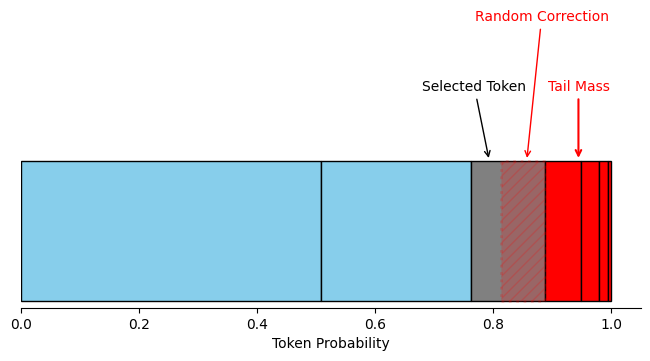

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import normalize

# Set the XKCD style

threshold = 0.9
with NoOpContextManager(): # plt.xkcd()
    # Create data for decreasing segments
    widths = normalize(np.asarray([[100, 50, 25, 12, 6, 3, 1]]), norm = 'l1').ravel()
    print(widths)
    lefts = np.zeros_like(widths)
    for i in range(1, len(widths)):
        lefts[i] = lefts[i-1] + widths[i-1]

    # Create the bar plot with segments - reduced height for a thinner bar
    fig, ax = plt.subplots(figsize=(8, 2))  # Reduced height from 6 to 2
    colors = [ 'red' if x > threshold else 'gray' if x > 0.8 else 'skyblue' for x in np.cumsum(widths) ]
    for i in range(len(widths)):
        ax.barh(0, widths[i], left=lefts[i], height=0.2, color=colors[i], edgecolor='black')  # Reduced height from 0.5 to 0.2
        # Add text to each bar segment
        #if widths[i] > 0.05:  # Only add text if segment is wide enough
        #    ax.text(lefts[i] + widths[i]/2, 0, f"Token {i+1}", 
        #            ha='center', va='center', fontsize=8, color='black', alpha = 0.4)

    # Find the gray segment indices
    gray_indices = [i for i, color in enumerate(colors) if color == 'gray']
    if gray_indices:
        # Calculate the start and end of gray segment
        start = lefts[gray_indices[0]]
        end = start + widths[gray_indices[0]]
        
        # Add arrow spanning the gray segment
        arrow_y = 0.1  # Place at the top of the bars

        line_x = start + 0.4 * (end - start)

        # Add "Selected Token" annotation
        ax.annotate("Selected Token", 
                    xy=((start*0.75 + end*0.25), 0.1), 
                    xytext=((start*0.95 + end*0.05), 0.2),
                    fontsize=10, ha='center', 
                    arrowprops=dict(arrowstyle='->', color='black', lw=1))


        # Add outlined rectangle from dotted line to end of main bar with dotted red border
        rect_width = 0.59 * (end - start)  # End of bar (1.0) minus line position
        rect_patch = plt.Rectangle((line_x, -0.1), rect_width, 0.2, 
                                fill=True, zorder=3, edgecolor='red', 
                                linewidth=2, linestyle=':', 
                                facecolor='red', alpha=0.2, hatch='///')
        ax.add_patch(rect_patch)
        
        # Add "Random Correction" annotation
        ax.annotate("Random Correction", 
                    xy=((start*0.25 + end*0.75), 0.1), 
                    xytext=((start*0.05 + end*0.95), 0.3),
                    fontsize=10, ha='center', color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=1))
        
    # Add annotation for red bars (tail mass)
    red_indices = [i for i, color in enumerate(colors) if color == 'red']
    if red_indices:
        red_start = lefts[red_indices[0]]
        red_end = 1.0  # End of the bar
        # Calculate center of red bars
        red_center = red_start + (red_end - red_start) / 2
        # Add "Tail Mass" annotation with red arrow and text
        ax.annotate("Tail Mass", 
                    xy=(red_center, 0.1), 
                    xytext=(red_center, 0.2),
                    fontsize=10, ha='center', color='red', 
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

    # Remove axes
    ax.set_xlabel("Token Probability")
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    plt.tight_layout()
    plt.show()


findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

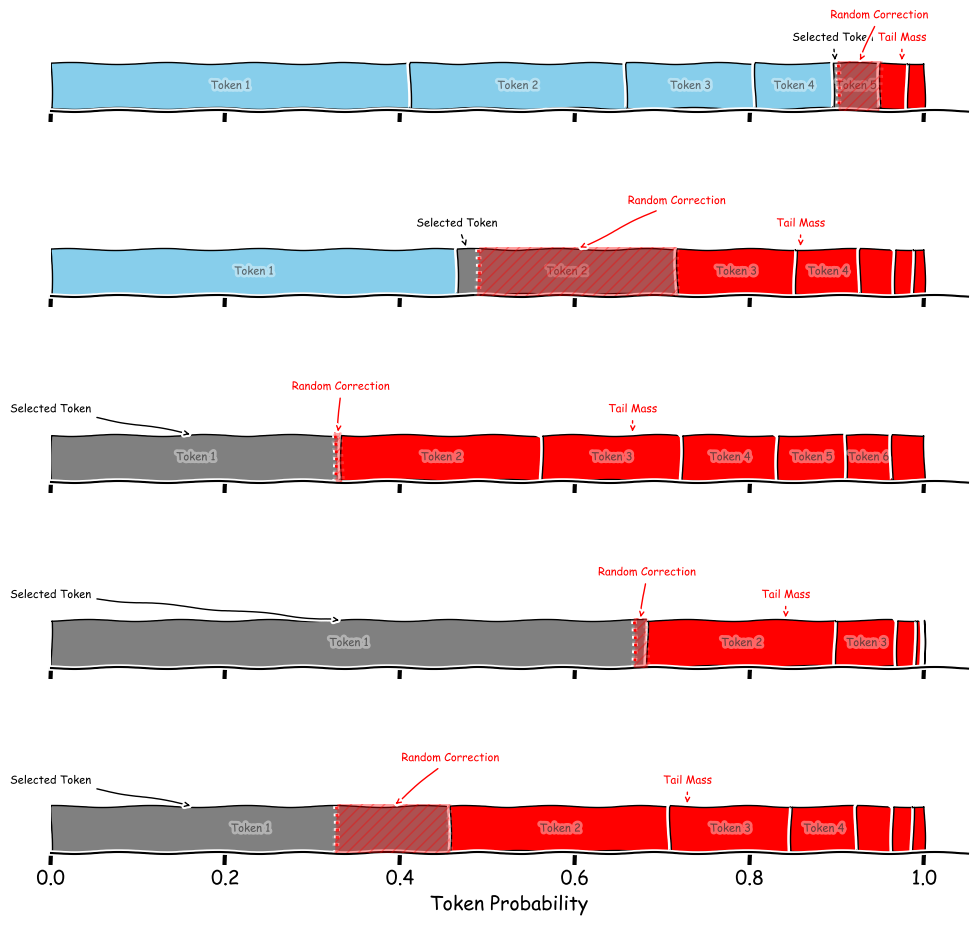

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import normalize

# Set the XKCD style
#plt.xkcd()
with NoOpContextManager():
    # Create figure with multiple subplots
    fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
    plt.subplots_adjust(hspace=0.5)

    for ax_idx, ax in enumerate(axes):
        # Random threshold for each plot between 0 and 1
        threshold = np.random.uniform(0, 1)
        
        # Create data for decreasing segments
        alpha = np.random.uniform(0.3, 0.7)
        widths = normalize(np.asarray([[100*(alpha**i) for i in range(7)]]), norm='l1').ravel()
        lefts = np.zeros_like(widths)
        for i in range(1, len(widths)):
            lefts[i] = lefts[i-1] + widths[i-1]
        
        # Find which segment contains the threshold
        cumsum = np.cumsum(widths)
        threshold_idx = np.searchsorted(cumsum, threshold)
        
        # Create colors based on threshold position
        colors = []
        for i, (left, width) in enumerate(zip(lefts, widths)):
            right = left + width
            if left <= threshold < right:  # This segment contains the threshold
                colors.append('gray')
            elif right <= threshold:  # Segments to the left of threshold
                colors.append('skyblue')
            else:  # Segments to the right of threshold
                colors.append('red')
        
        # Create the bar plot with segments
        for i in range(len(widths)):
            ax.barh(0, widths[i], left=lefts[i], height=0.2, color=colors[i], edgecolor='black')
            if widths[i] > 0.05:
                ax.text(lefts[i] + widths[i]/2, 0, f"Token {i+1}", 
                        ha='center', va='center', fontsize=8, color='black', alpha=0.4)
        
        # Find the gray segment index (should be only one)
        gray_idx = colors.index('gray') if 'gray' in colors else None
        if gray_idx is not None:
            start = lefts[gray_idx]
            end = start + widths[gray_idx]
            
            # Calculate where in the segment the threshold falls
            segment_position = (threshold - start) / widths[gray_idx]
            
            # Add dotted red line at threshold
            ax.axvline(x=threshold, color='red', linestyle=':', linewidth=2, ymin=0, ymax=1)
            
            # Cross-hatched rectangle from threshold to end of gray segment
            hatch_start = threshold
            hatch_width = end - threshold
            
            # Add cross-hatched rectangle
            rect_patch = plt.Rectangle((hatch_start, -0.2), hatch_width, 0.6, 
                                    fill=True, zorder=3, edgecolor='red', 
                                    linewidth=2, linestyle=':', 
                                    facecolor='red', alpha=0.2, hatch='///')
            ax.add_patch(rect_patch)
            
            # Add annotations
            ax.annotate("Selected Token", 
                        xy=((start + threshold)/2, 0.1), 
                        xytext=(start, 0.2),
                        fontsize=8, ha='center', 
                        arrowprops=dict(arrowstyle='->', color='black', lw=1))
            
            ax.annotate("Random Correction", 
                        xy=(hatch_start + hatch_width/2, 0.1), 
                        xytext=(end, 0.3),
                        fontsize=8, ha='center', color='red',
                        arrowprops=dict(arrowstyle='->', color='red', lw=1))
        
        # Add annotation for red bars (tail mass)
        red_indices = [i for i, color in enumerate(colors) if color == 'red']
        if red_indices:
            red_start = lefts[red_indices[0]]
            red_end = 1.0
            red_center = red_start + (red_end - red_start) / 2
            ax.annotate("Tail Mass", 
                        xy=(red_center, 0.1), 
                        xytext=(red_center, 0.2),
                        fontsize=8, ha='center', color='red', 
                        arrowprops=dict(arrowstyle='->', color='red', lw=1))
        
        # Remove axes
        if ax_idx == len(axes)-1:
            ax.set_xlabel("Token Probability")
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)

    plt.tight_layout()
    plt.show()


findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

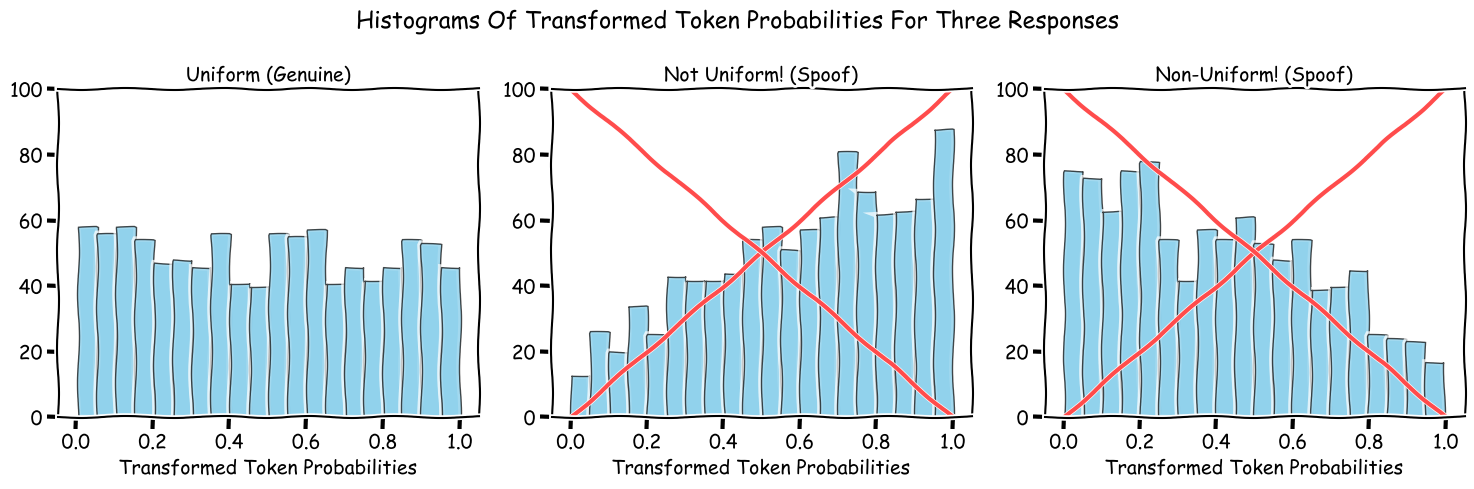

In [143]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Set the seed for reproducibility
np.random.seed(42)

# Generate data
uniform_data = np.random.uniform(0, 1, 1000)
left_skewed_data = np.random.beta(1.5, 1, 1000)  # alpha > beta creates right skew
right_skewed_data = np.random.beta(1, 1.5, 1000)  # alpha < beta creates left skew

with plt.xkcd():  # Enable xkcd style
    # Create figure with GridSpec for better control over subplot layout
    fig = plt.figure(figsize=(15, 5))
    gs = GridSpec(1, 3, figure=fig)
    
    # Uniform distribution plot
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(uniform_data, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.set_title("Uniform (Genuine)", fontsize=14)
    ax1.set_ylim(0, 100)
    ax1.set_xlabel("Transformed Token Probabilities")
    
    # Left skewed distribution plot
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(left_skewed_data, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax2.set_title("Not Uniform! (Spoof)", fontsize=14)
    ax2.set_ylim(0, 100)
    ax2.set_xlabel("Transformed Token Probabilities")
    # Add red X overlay
    ax2.plot([0, 1], [0, 100], color='red', linewidth=3, alpha=0.7)
    ax2.plot([0, 1], [100, 0], color='red', linewidth=3, alpha=0.7)
    
    # Right skewed distribution plot
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.hist(right_skewed_data, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax3.set_title("Non-Uniform! (Spoof)", fontsize=14)
    ax3.set_ylim(0, 100)
    ax3.set_xlabel("Transformed Token Probabilities")
    # Add red X overlay
    ax3.plot([0, 1], [0, 100], color='red', linewidth=3, alpha=0.7)
    ax3.plot([0, 1], [100, 0], color='red', linewidth=3, alpha=0.7)
    
    plt.suptitle("Histograms Of Transformed Token Probabilities For Three Responses")
    plt.tight_layout()
    plt.show()
